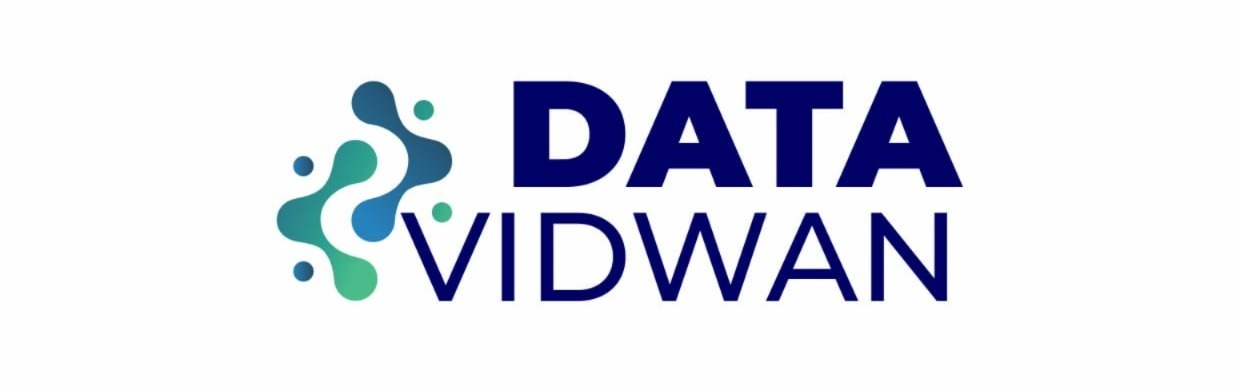

# **Logistic Regression**

- Logistic Regression is a classification algorithm used to predict categories like yes/no, spam/not spam, disease/no disease, etc.
- It gives the probability of something belonging to a class.

**Why we use it**
- When our output is categorical, not continuous.
- It helps to predict the chance (probability) of an event.
- It’s simple, fast, and works well when data is linearly separable.

**Where we use it**
- Predicting if an email is spam or not.
- Predicting if a student will pass or fail based on study hours.
- Predicting if a customer will buy a product.
- Medical field: disease detection (e.g., diabetes yes/no).

Probability = 1 / (1 + e^(-z))

- If the probability > 0.5 → predict 1 (Yes)
- If probability ≤ 0.5 → predict 0 (No)


**Why it matters**

- Helps in decision-making using probabilities.
- Works great for binary classification problems.
- Forms the base for advanced classification models.

Problem Statement

A financial institution wants to predict whether a customer will default on their credit payments. Defaulting on payments creates significant financial risk for the bank, including revenue loss and increased cost of collection. The dataset includes customer information such as income, age, credit usage, past payment behavior, and outstanding balances.

In this context:

Default = 1 means the customer is likely not going to make the payment, indicating high financial risk.

Default = 0 means the customer will make the payment, indicating low financial risk.

The objective of this project is to build a machine learning model that accurately classifies customers into default or non-default categories. This will help the finance department take data-driven decisions related to credit approvals and risk management.

**Libraries**

In [ ]:
import pandas as pd                 # for data handling
import numpy as np                  # for numerical operations
import matplotlib.pyplot as plt     # for data visualization
import seaborn as sns               # for better visual plots
from sklearn.model_selection import train_test_split   # to split dataset
from sklearn.linear_model import LogisticRegression     # logistic regression model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve  # for evaluation
import joblib                       # to save the trained model

**Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Logistic_Regression.xlsx to Logistic_Regression.xlsx


In [ ]:
df = pd.read_excel('credit_card_fraud.xlsx')
df.head()

,Age,Annual_Income,Credit_Score,Loan_Amount,Default
0,56,114071,386,46680,1
1,46,26640,400,9733,0
2,32,64547,307,35954,1
3,60,74620,499,36135,0
4,25,35317,804,12081,0


**Data Exploration (EDA)**

In [ ]:
# Check shape of dataset
print("Shape of dataset:", df.shape)

# Check column info
print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Basic statistics
print("\nStatistical Summary:")
print(df.describe())

Shape of dataset: (1500, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            1500 non-null   int64
 1   Annual_Income  1500 non-null   int64
 2   Credit_Score   1500 non-null   int64
 3   Loan_Amount    1500 non-null   int64
 4   Default        1500 non-null   int64
dtypes: int64(5)
memory usage: 58.7 KB

Missing Values:
 Age              0
Annual_Income    0
Credit_Score     0
Loan_Amount      0
Default          0
dtype: int64

Statistical Summary:
               Age  Annual_Income  Credit_Score   Loan_Amount      Default
count  1500.000000    1500.000000    1500.00000   1500.000000  1500.000000
mean     41.285333   86531.701333     579.16600  27603.088000     0.414667
std      13.480495   37860.430553     158.60924  12845.189642     0.492829
min      18.000000   20163.000000     300.00000   5016.000000     0.00

**Split Data & Train**

In [ ]:
# Separate features (X) and target (y)
X = df.drop('Default', axis=1)
y = df['Default']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


**Model Evaluation**

Accuracy: 0.8433333333333334

Confusion Matrix:
 [[151  22]
 [ 25 102]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.87       173
           1       0.82      0.80      0.81       127

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300

ROC-AUC Score: 0.9342314869600837


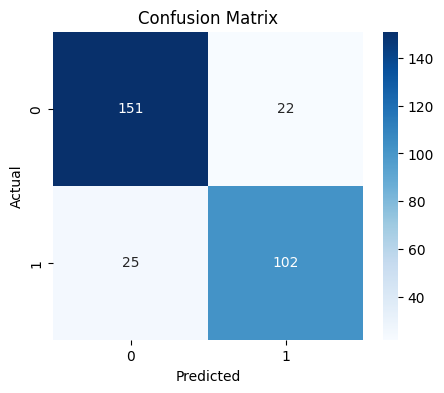

In [ ]:
# Step 5: Model Evaluation

# Make predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", roc_auc)

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC AUC stands for Receiver Operating Characteristic – Area Under the Curve.

**In short**
- ROC curve plots True Positive Rate vs False Positive Rate at different thresholds.
- AUC measures how well the model distinguishes between classes.
- Values range from 0 to 1.

**How to interpret AUC**

- 0.5 → No discrimination (random guessing)
- 0.7 – 0.8 → Acceptable
- 0.8 – 0.9 → Good
- 0.9 → Excellent

|              | Predicted 0 | Predicted 1 |
| ------------ | ----------- | ----------- |
| **Actual 0** | 151 (TN)    | 22 (FP)     |
| **Actual 1** | 25 (FN)     | 102 (TP)    |


**Meaning of each term**

**True Positive (TP = 102):**
- Actual = 1, Predicted = 1 → model correctly predicted “Default”.

**True Negative (TN = 151):**
- Actual = 0, Predicted = 0 → model correctly predicted “No Default”.

**False Positive (FP = 22):**
- Actual = 0, Predicted = 1 → model predicted “Default” when it wasn’t (type I error).

**False Negative (FN = 25):**
- Actual = 1, Predicted = 0 → model missed a real “Default” (type II error).

**How to interpret your results**

- Accuracy = 0.84 (84%) → the model is correct 84% of the time.
- Precision (1) = 0.82 → when the model predicts “Default”, it’s correct 82% of the time.
- Recall (1) = 0.80 → the model catches 80% of all actual defaulters.
- F1-score = 0.81 → balance between precision and recall.

**Inference**

In [ ]:
# Example: new data of one person
new_data = pd.DataFrame({
    'Age': [56],
    'Annual_Income': [114071],
    'Credit_Score': [386],
    'Loan_Amount': [46680]
})

# Predict probability and class
probability = model.predict_proba(new_data)[:, 1][0]
prediction = model.predict(new_data)[0]

print("Predicted Probability of Default:", round(probability, 2))
print("Predicted Class (0 = No Default, 1 = Default):", prediction)

Predicted Probability of Default: 1.0
Predicted Class (0 = No Default, 1 = Default): 1


**Save the model**

In [ ]:
# Step 6: Save the trained model

import joblib

# Save the model to a file
joblib.dump(model, 'logistic_regression_model.pkl')

print("Model saved successfully as 'logistic_regression_model.pkl'")

Model saved successfully as 'logistic_regression_model.pkl'
